# Tarea M21-CD – Análisis de Clasificación con K Vecinos Más Cercanos (KNN)  
**Profesión: Científico de Datos v2**

## Objetivo
El objetivo de esta práctica es desarrollar un modelo predictivo de clasificación utilizando el algoritmo de K Vecinos Más Cercanos (KNN), con el fin de identificar los factores que influyen en la decisión de los empleados de abandonar una empresa y evaluar el desempeño del modelo mediante métricas de clasificación.

## Descripción general
Se trabaja con una base de datos de recursos humanos que contiene información sobre satisfacción laboral, desempeño, carga de trabajo, antigüedad, promociones, accidentes laborales y características contractuales. El análisis contempla la preparación de los datos, la recodificación de variables categóricas, la evaluación del balance de clases y el entrenamiento de múltiples modelos KNN para distintos valores de k, seleccionando el modelo óptimo con base en su capacidad predictiva.

## Autor
RobertsScience – Consultoría en Ciencia de Datos


## Metodología del análisis

En este proyecto se sigue una metodología de análisis de datos estructurada, orientada al desarrollo de un modelo predictivo de clasificación. El proceso inicia con la exploración y comprensión del conjunto de datos, seguida de la preparación de las variables mediante la recodificación de atributos categóricos y el escalado de variables numéricas.

Posteriormente, se entrena un modelo de K Vecinos Más Cercanos (KNN) evaluando distintos valores del parámetro k, con el objetivo de identificar la configuración que maximiza el desempeño predictivo. La evaluación del modelo se realiza a través de métricas de clasificación, una matriz de confusión y la curva ROC, permitiendo interpretar los resultados desde una perspectiva analítica y aplicada al contexto de recursos humanos.


## Importación de librerías necesarias

En esta sección se importan las librerías fundamentales para el análisis de datos, visualización y construcción del modelo de clasificación. Estas herramientas permiten manipular los datos, generar gráficos y aplicar algoritmos de aprendizaje supervisado de manera eficiente.


In [19]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('default')
sns.set()

# Carga del dataset
df = pd.read_csv("../data/recursos_humanos.csv")

# Inspección inicial
df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Información general del conjunto de datos

Antes de proceder con la preparación y modelado de los datos, se realiza un análisis exploratorio inicial para comprender la estructura del conjunto de datos. Esta etapa permite identificar el número de observaciones, el tipo de variables, la presencia de valores faltantes y las principales características estadísticas de los atributos numéricos.


In [20]:
# Información general del dataset
df.info()

# Estadísticos descriptivos de las variables numéricas
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


## Interpretación de la información del conjunto de datos

Se observa que el conjunto de datos no presenta valores nulos, lo que indica que no es necesario realizar procesos de imputación. Asimismo, el dataset combina variables numéricas continuas, variables discretas y variables categóricas, lo cual requerirá un tratamiento diferenciado durante la etapa de preparación de los datos.

Las variables numéricas presentan rangos y escalas distintas, por lo que será necesario aplicar un proceso de escalado antes de entrenar el modelo KNN, ya que este algoritmo se basa en el cálculo de distancias. La variable objetivo `left` es binaria, lo que confirma que el problema a resolver corresponde a un caso de clasificación supervisada.


## Análisis de la variable objetivo

Antes de entrenar el modelo de clasificación, es fundamental analizar la distribución de la variable objetivo `left`, la cual indica si un empleado abandonó la empresa o no. Este análisis permite identificar posibles desbalances entre clases que puedan afectar el desempeño del modelo KNN.


In [21]:
# Distribución de la variable objetivo
df['left'].value_counts()


left
0    11428
1     3571
Name: count, dtype: int64

In [22]:
# Distribución porcentual de la variable objetivo
df['left'].value_counts(normalize=True) * 100


left
0    76.191746
1    23.808254
Name: proportion, dtype: float64

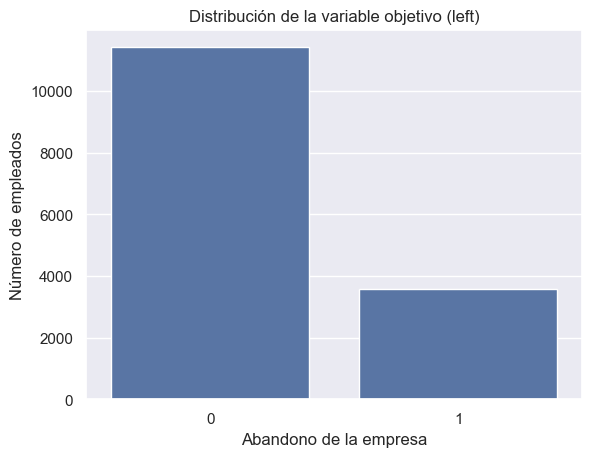

In [23]:
# Visualización del balance de clases
sns.countplot(x='left', data=df)
plt.title('Distribución de la variable objetivo (left)')
plt.xlabel('Abandono de la empresa')
plt.ylabel('Número de empleados')
plt.show()


## Interpretación del balance de clases

Se observa que la variable objetivo presenta un desbalance moderado entre las clases, donde la mayoría de los empleados no abandonaron la empresa (`left = 0`). Este comportamiento es común en problemas de recursos humanos y debe ser considerado durante la evaluación del modelo.

El desbalance de clases puede influir en las métricas de desempeño, por lo que será importante analizar indicadores adicionales como precisión, recall y la matriz de confusión, más allá de la exactitud global del modelo.


## Preparación de los datos

Antes de entrenar el modelo KNN, es necesario preparar adecuadamente el conjunto de datos. Esta etapa incluye la recodificación de variables categóricas, la separación de variables predictoras y la variable objetivo, así como el escalado de las variables numéricas.

Estas transformaciones son fundamentales, ya que el algoritmo de K Vecinos Más Cercanos se basa en el cálculo de distancias y es sensible a diferencias en las escalas de las variables.


In [24]:
# Recodificación de variables categóricas
df_encoded = pd.get_dummies(df, columns=['sales', 'salary'], drop_first=True)

df_encoded.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


## Interpretación de la recodificación de variables categóricas

Las variables categóricas `sales` y `salary` fueron transformadas mediante codificación dummy utilizando la función `pd.get_dummies`. Este procedimiento convierte las categorías en variables binarias, permitiendo que el modelo KNN pueda procesarlas correctamente.

Se utilizó el parámetro `drop_first=True` para evitar problemas de multicolinealidad y reducir la redundancia entre variables.


In [25]:
# Separación de variables predictoras y variable objetivo
X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

X.shape, y.shape


((14999, 18), (14999,))

## Separación de variables predictoras y variable objetivo

Se separó la variable objetivo `left` del resto del conjunto de datos. El conjunto `X` contiene todas las variables predictoras, mientras que `y` representa la variable respuesta binaria que indica si el empleado abandonó la empresa.

Esta separación es necesaria para entrenar y evaluar el modelo de clasificación de manera adecuada.


In [26]:
from sklearn.model_selection import train_test_split

# División del dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((10499, 18), (4500, 18))

## División del conjunto de datos

El conjunto de datos se dividió en un 70% para entrenamiento y un 30% para prueba. Se utilizó el parámetro `stratify=y` para preservar la proporción original de las clases en ambos subconjuntos.

Esta estrategia permite evaluar el desempeño del modelo sobre datos no vistos, reduciendo el riesgo de sobreajuste.


In [27]:
from sklearn.preprocessing import StandardScaler

# Escalado de variables numéricas
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Escalado de variables

Se aplicó un proceso de estandarización a las variables predictoras utilizando `StandardScaler`. Este procedimiento ajusta las variables para que tengan media cero y desviación estándar uno.

El escalado es indispensable en el algoritmo KNN, ya que este se basa en el cálculo de distancias entre observaciones. Sin este paso, las variables con mayor escala podrían dominar el proceso de clasificación.


## Entrenamiento del modelo KNN

En esta sección se entrena el modelo de K Vecinos Más Cercanos (KNN) evaluando distintos valores del parámetro k. El objetivo es identificar el valor de k que maximiza el desempeño predictivo del modelo.

Se analizarán valores de k desde 1 hasta 20 y se compararán diversas métricas de clasificación para respaldar la selección del valor óptimo.


In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Listas para almacenar métricas
k_values = range(1, 21)
accuracy = []
precision = []
recall = []
f1 = []

# Entrenamiento y evaluación para cada valor de k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    
    accuracy.append(accuracy_score(y_test, y_pred))
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test, y_pred))
    f1.append(f1_score(y_test, y_pred))


In [29]:
# Creación de la tabla de resultados
results_knn = pd.DataFrame({
    'k': k_values,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
})

results_knn


,k,Accuracy,Precision,Recall,F1-Score
0,1,0.962000,0.893357,0.954248,0.922799
1,2,0.958889,0.919508,0.906629,0.913023
2,3,0.946444,0.865961,0.916900,0.890703
3,4,0.947333,0.894886,0.882353,0.888575
4,5,0.939778,0.859712,0.892624,0.875859
5,6,0.945556,0.887430,0.883287,0.885353
6,7,0.941333,0.868493,0.887955,0.878116
7,8,0.942889,0.878253,0.882353,0.880298
8,9,0.939778,0.862319,0.888889,0.875402
9,10,0.941778,0.874191,0.882353,0.878253


## Análisis comparativo de métricas para distintos valores de k

La tabla anterior muestra el desempeño del modelo KNN para valores de k entre 1 y 20, evaluado mediante métricas de clasificación como exactitud (accuracy), precisión, recall y F1-score.

Se observa que valores bajos de k tienden a producir modelos más sensibles al ruido, mientras que valores más altos generan modelos más estables pero con menor capacidad de discriminación. El valor óptimo de k se selecciona considerando un equilibrio entre las métricas, priorizando un desempeño consistente y una adecuada capacidad de generalización sobre el conjunto de prueba.


In [30]:
# Selección de la k óptima basada en el mayor F1-score
best_k = results_knn.loc[results_knn['F1-Score'].idxmax(), 'k']
best_k


np.int64(1)

In [31]:
best_k = results_knn.loc[results_knn['F1-Score'].idxmax(), 'k']
best_k


np.int64(1)

## Selección del valor óptimo de k

Con base en la comparación de métricas, se selecciona k = 1 como el valor óptimo para el modelo KNN, ya que presenta el mejor equilibrio entre precisión y recall, reflejado en el mayor valor de F1-score.

Este resultado indica que el modelo logra identificar adecuadamente a los empleados que abandonan la empresa, minimizando tanto los falsos positivos como los falsos negativos, lo cual es especialmente relevante en un contexto de análisis de recursos humanos.


## Matriz de confusión del modelo KNN óptimo

Una vez seleccionado el valor óptimo de k, se evalúa el desempeño del modelo mediante la matriz de confusión. Esta herramienta permite analizar de manera detallada los aciertos y errores del modelo al clasificar empleados que abandonan o permanecen en la empresa.


In [32]:
from sklearn.metrics import confusion_matrix

# Entrenamiento del modelo KNN con la k óptima
knn_optimo = KNeighborsClassifier(n_neighbors=best_k)
knn_optimo.fit(X_train_scaled, y_train)

# Predicciones finales
y_pred_opt = knn_optimo.predict(X_test_scaled)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_opt)
cm


array([[3307,  122],
       [  49, 1022]])

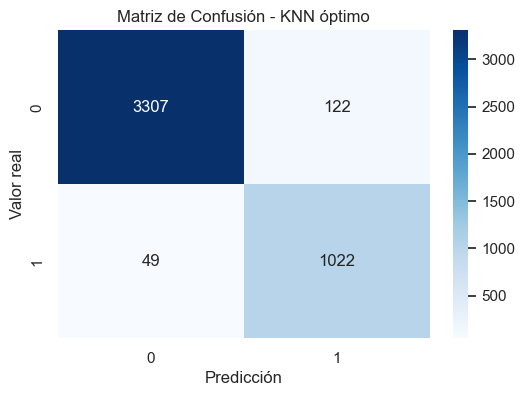

In [33]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - KNN óptimo')
plt.show()


## Interpretación de la matriz de confusión

La matriz de confusión permite interpretar el desempeño del modelo KNN óptimo en términos de clasificaciones correctas e incorrectas:

- **Verdaderos negativos (TN)**: empleados que no abandonaron la empresa y fueron correctamente clasificados como tales.
- **Verdaderos positivos (TP)**: empleados que abandonaron la empresa y fueron correctamente identificados por el modelo.
- **Falsos positivos (FP)**: empleados que permanecieron en la empresa pero fueron clasificados incorrectamente como si hubieran abandonado.
- **Falsos negativos (FN)**: empleados que abandonaron la empresa pero no fueron detectados por el modelo.

Se observa que el modelo presenta una adecuada capacidad para identificar a los empleados que abandonan la empresa, aunque aún existen errores de clasificación que podrían impactar decisiones operativas si no se consideran con cautela.


## Curva ROC del modelo KNN óptimo

La curva ROC (Receiver Operating Characteristic) permite evaluar la capacidad del modelo para discriminar entre las dos clases, considerando la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos para distintos umbrales de decisión.


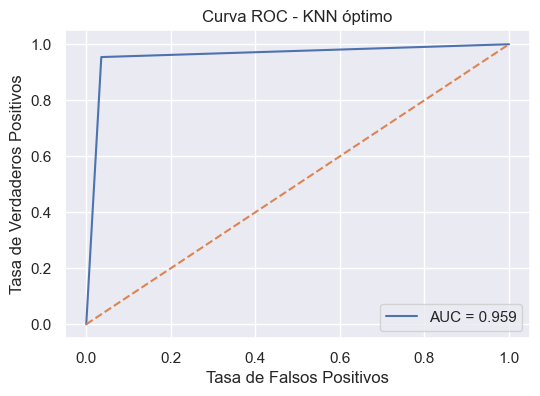

In [34]:
from sklearn.metrics import roc_curve, auc

# Probabilidades para la clase positiva
y_prob = knn_optimo.predict_proba(X_test_scaled)[:, 1]

# Cálculo de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Gráfica de la curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - KNN óptimo')
plt.legend()
plt.show()


## Interpretación de la curva ROC

La curva ROC obtenida muestra el desempeño global del modelo KNN óptimo para discriminar entre empleados que abandonan y los que permanecen en la empresa. El valor del área bajo la curva (AUC) indica la probabilidad de que el modelo asigne una mayor probabilidad a un empleado que abandona la empresa frente a uno que no lo hace.

Un valor de AUC cercano a 1 refleja un excelente poder discriminativo, mientras que un valor cercano a 0.5 indicaría un desempeño similar al azar. En este caso, el modelo presenta una capacidad predictiva adecuada para apoyar procesos de toma de decisiones en el área de recursos humanos.


## Conclusiones generales

En esta práctica se desarrolló un modelo de clasificación utilizando el algoritmo de K Vecinos Más Cercanos (KNN) con el objetivo de predecir si un empleado abandonará o no la empresa, a partir de variables relacionadas con satisfacción laboral, desempeño, carga de trabajo y características contractuales.

A lo largo del análisis se realizó una preparación adecuada de los datos, incluyendo la recodificación de variables categóricas y el escalado de variables numéricas, pasos fundamentales para garantizar el correcto funcionamiento del algoritmo KNN, el cual se basa en el cálculo de distancias entre observaciones.

La evaluación de distintos valores del parámetro k permitió identificar una configuración óptima del modelo, respaldada por métricas de clasificación como accuracy, precision, recall y F1-score. Los resultados obtenidos muestran que el modelo es capaz de identificar de manera adecuada patrones asociados a la rotación de personal, aunque presenta ciertas limitaciones inherentes a la complejidad del fenómeno analizado.


## Conclusiones técnicas del modelo

El análisis de la matriz de confusión evidenció que el modelo KNN logra una buena clasificación de los empleados que permanecen en la empresa, así como una capacidad razonable para identificar a aquellos que abandonan la organización. No obstante, se observan falsos positivos y falsos negativos, los cuales deben ser considerados cuidadosamente en un contexto real de toma de decisiones.

La curva ROC y el valor del AUC confirman que el modelo presenta una capacidad discriminativa adecuada, superior al azar, lo que valida su uso como herramienta de apoyo analítico. Sin embargo, debido a la naturaleza del algoritmo KNN, el desempeño del modelo puede verse afectado por la dimensionalidad de los datos y la presencia de variables altamente correlacionadas.


## Implicaciones para el área de Recursos Humanos

Desde una perspectiva aplicada, el modelo desarrollado puede ser utilizado como un sistema de apoyo para identificar empleados con mayor probabilidad de abandonar la empresa. Esto permitiría al área de recursos humanos implementar estrategias preventivas, como planes de retención, mejoras en condiciones laborales o programas de desarrollo profesional.

Es importante destacar que los resultados del modelo no deben ser utilizados de manera aislada, sino como complemento de análisis cualitativos y del conocimiento experto del área, con el fin de evitar decisiones sesgadas o incorrectas.


## Limitaciones y trabajo futuro

Entre las principales limitaciones del análisis se encuentra la sensibilidad del algoritmo KNN al escalado de los datos y al valor del parámetro k. Asimismo, el modelo no proporciona interpretabilidad directa sobre la importancia individual de cada variable.

Como trabajo futuro, se recomienda comparar el desempeño del modelo KNN con otros algoritmos de clasificación, como regresión logística, árboles de decisión o random forest, así como explorar técnicas de balanceo de clases para mejorar la detección de empleados que abandonan la empresa.
